In [3]:
import pandas as pd

In [159]:
anime=pd.read_csv('anime.csv')
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [161]:
anime.shape

(12294, 7)

In [163]:
anime.columns.tolist()

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

# Data Cleaning

In [165]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [167]:
anime.nunique()

anime_id    12294
name        12292
genre        3264
type            6
episodes      187
rating        598
members      6706
dtype: int64

In [169]:
num_duplicates=anime.duplicated().sum()
num_duplicates

0

In [171]:
anime.dtypes

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

In [173]:
anime.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [175]:
anime['genre'] = anime['genre'].fillna(anime['genre'].mode()[0])
anime['type'] = anime['type'].fillna(anime['type'].mode()[0])
anime['rating'] = anime['rating'].fillna(anime['rating'].mode()[0])

In [177]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [179]:
anime.isna().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [181]:
anime.describe()

,anime_id,rating,members
count,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,6.465036,1.807134e+04
std,11455.294701,1.019121,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.900000,2.250000e+02
50%,10260.500000,6.550000,1.550000e+03
75%,24794.500000,7.170000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [183]:
import re

def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Normalize whitespace
    text = ' '.join(text.split())
    return text.strip()

anime['name'] = anime['name'].apply(clean_text)
anime['genre'] = anime['genre'].apply(clean_text)

In [185]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa,Drama Romance School Supernatural,Movie,1,9.37,200630
1,5114,Fullmetal Alchemist Brotherhood,Action Adventure Drama Fantasy Magic Military ...,TV,64,9.26,793665
2,28977,Gintama,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.25,114262
3,9253,SteinsGate,SciFi Thriller,TV,24,9.17,673572
4,9969,Gintama039,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.16,151266


# Cleaning the training data set

In [187]:
train=pd.read_csv('train.csv')
train.head()

,user_id,anime_id,rating
0,1,11617,10
1,1,11757,10
2,1,15451,10
3,2,11771,10
4,3,20,8


In [188]:
duplicated=train.duplicated().sum()
duplicated

1

In [190]:
train.drop_duplicates(subset=['user_id'],keep='first',inplace=True)

In [193]:
duplicated=train.duplicated().sum()
duplicated

0

In [195]:
train.describe()

,user_id,anime_id,rating
count,69481.000000,69481.000000,69481.000000
mean,36772.039752,762.695586,8.474259
std,21211.298683,2742.417111,1.430355
min,1.000000,1.000000,1.000000
25%,18420.000000,15.000000,8.000000
50%,36795.000000,27.000000,9.000000
75%,55117.000000,164.000000,10.000000
max,73516.000000,34240.000000,10.000000


# Feature Enginnerring

In [197]:
# Extract genres into list format for later processing
anime['genre_list'] = anime['genre'].str.split(',').apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])

# Create popularity bins
anime['popularity'] = pd.qcut(anime['members'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

In [199]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members,genre_list,popularity
0,32281,Kimi no Na wa,Drama Romance School Supernatural,Movie,1,9.37,200630,[Drama Romance School Supernatural],Very High
1,5114,Fullmetal Alchemist Brotherhood,Action Adventure Drama Fantasy Magic Military ...,TV,64,9.26,793665,[Action Adventure Drama Fantasy Magic Military...,Very High
2,28977,Gintama,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.25,114262,[Action Comedy Historical Parody Samurai SciFi...,Very High
3,9253,SteinsGate,SciFi Thriller,TV,24,9.17,673572,[SciFi Thriller],Very High
4,9969,Gintama039,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.16,151266,[Action Comedy Historical Parody Samurai SciFi...,Very High


# Explanatory Data Analysis

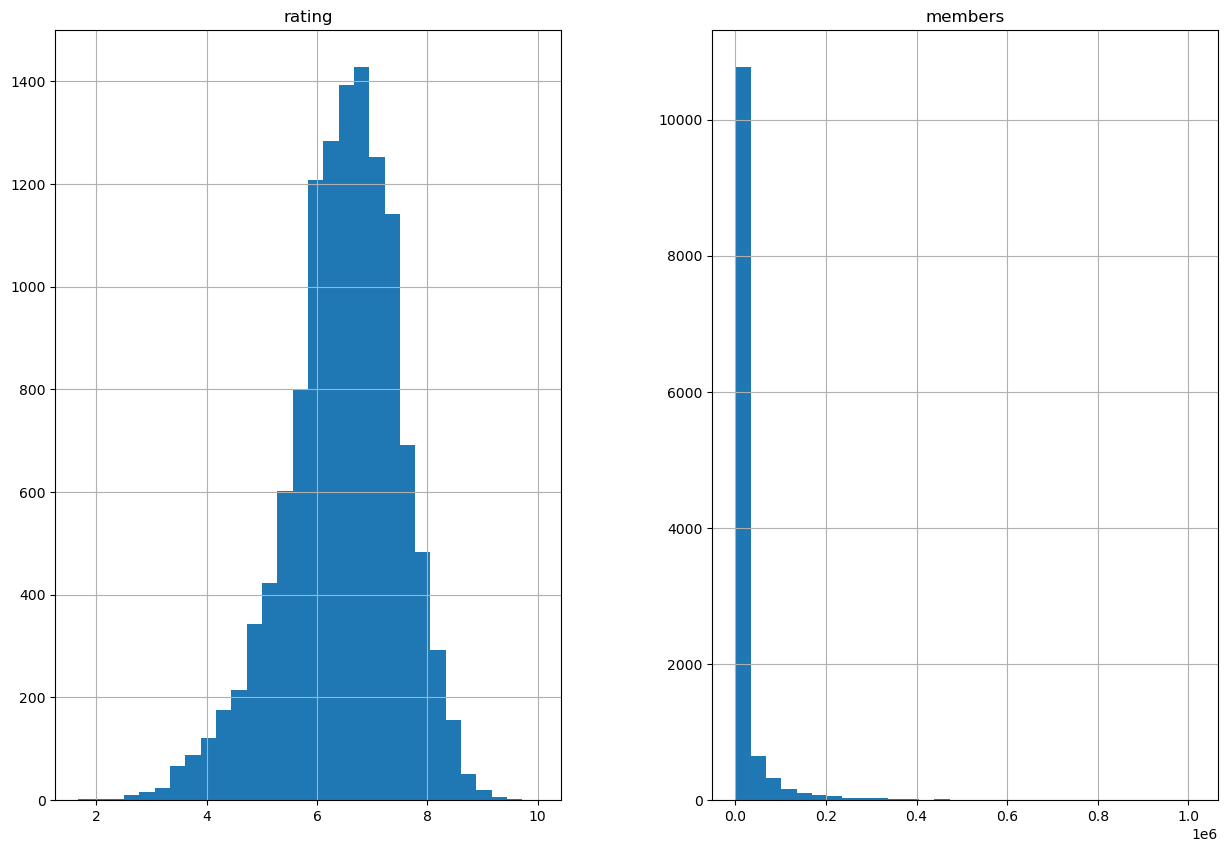

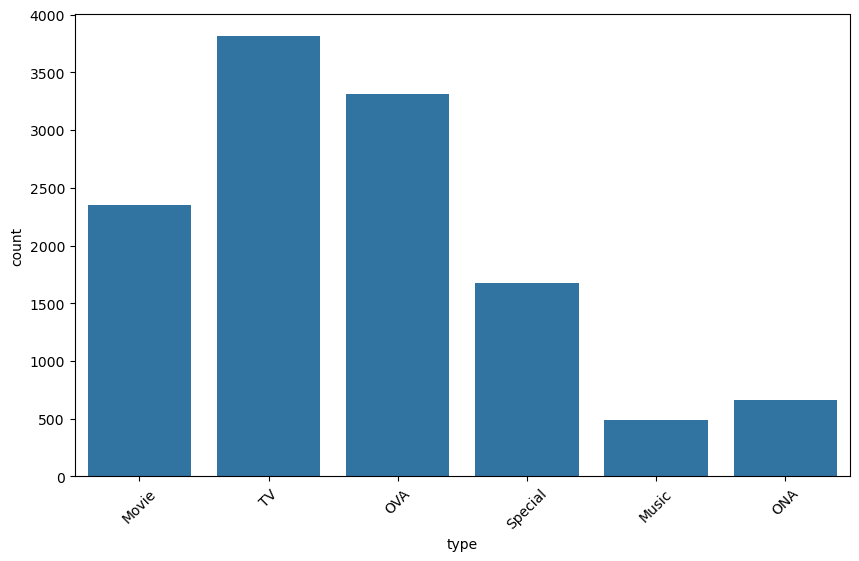

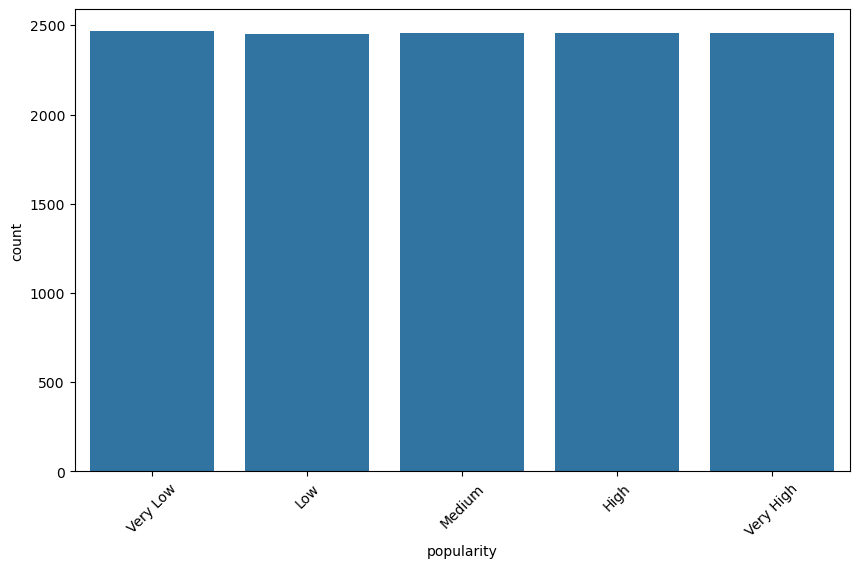

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['episodes', 'rating', 'members']
anime[num_cols].hist(bins=30, figsize=(15, 10))
plt.show()

# Categorical features
cat_cols = ['type', 'popularity']
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=anime, x=col)
    plt.xticks(rotation=45)
    plt.show()

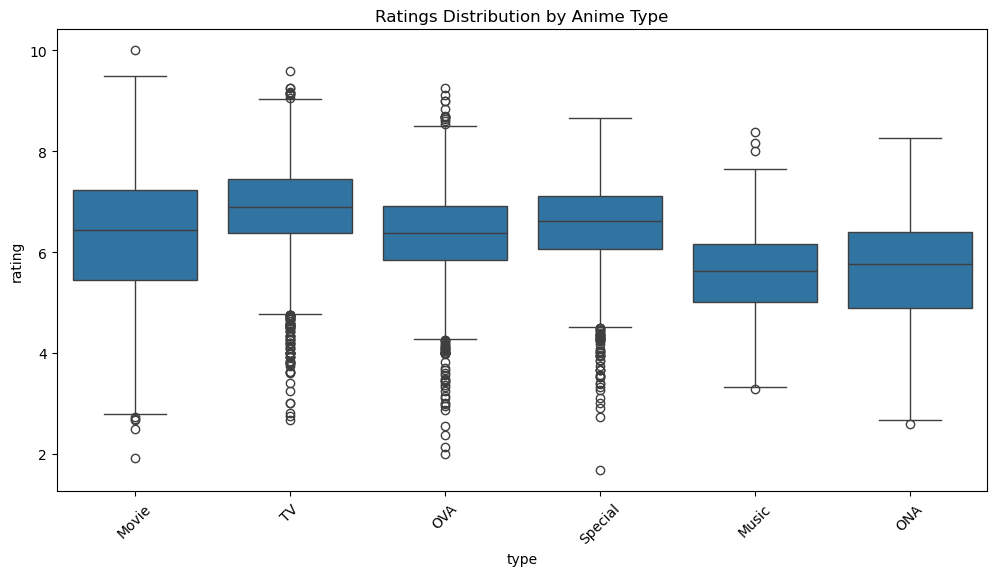

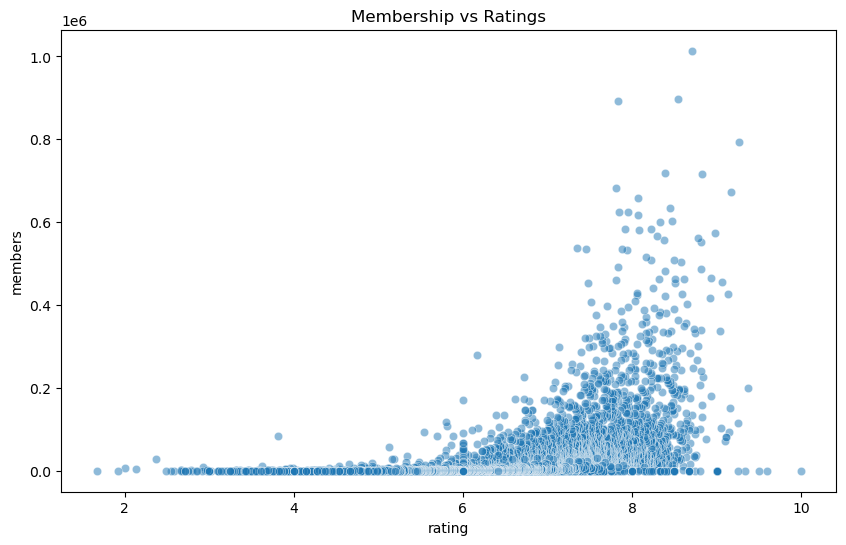

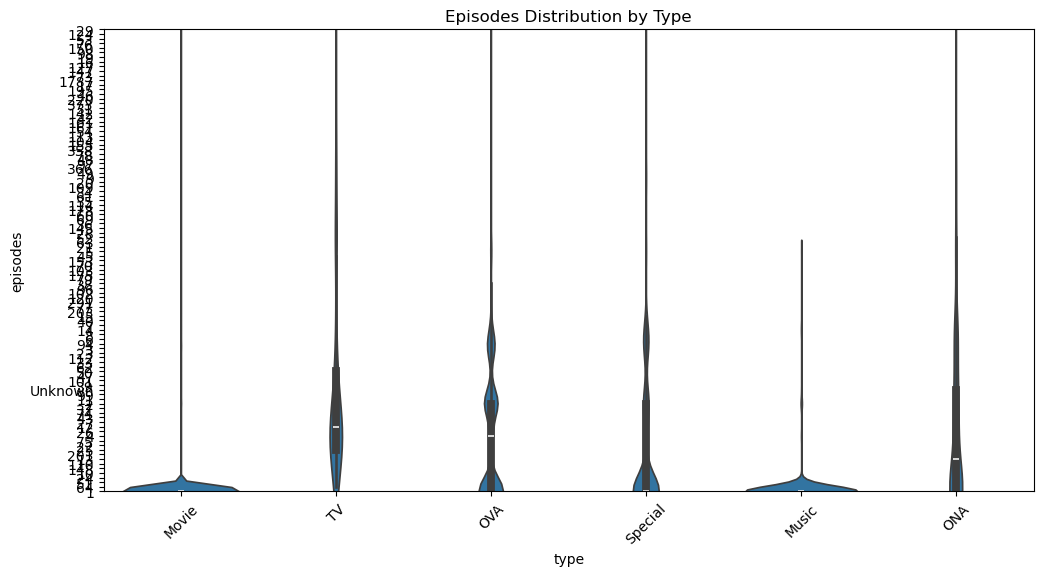

In [202]:
# Ratings vs Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=anime, x='type', y='rating')
plt.title('Ratings Distribution by Anime Type')
plt.xticks(rotation=45)
plt.show()

# Membership vs Ratings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anime, x='rating', y='members', alpha=0.5)
plt.title('Membership vs Ratings')
plt.show()

# Episodes distribution by type
plt.figure(figsize=(12, 6))
sns.violinplot(data=anime, x='type', y='episodes')
plt.ylim(0, 100)  # Limit to see most data clearly
plt.title('Episodes Distribution by Type')
plt.xticks(rotation=45)
plt.show()



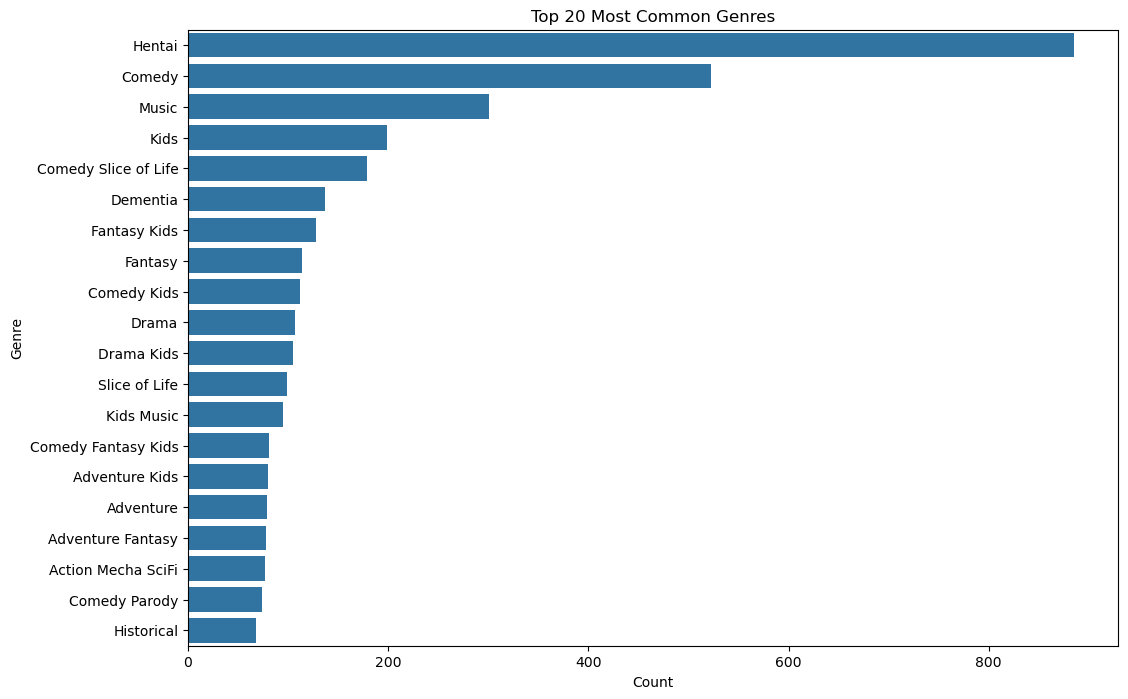

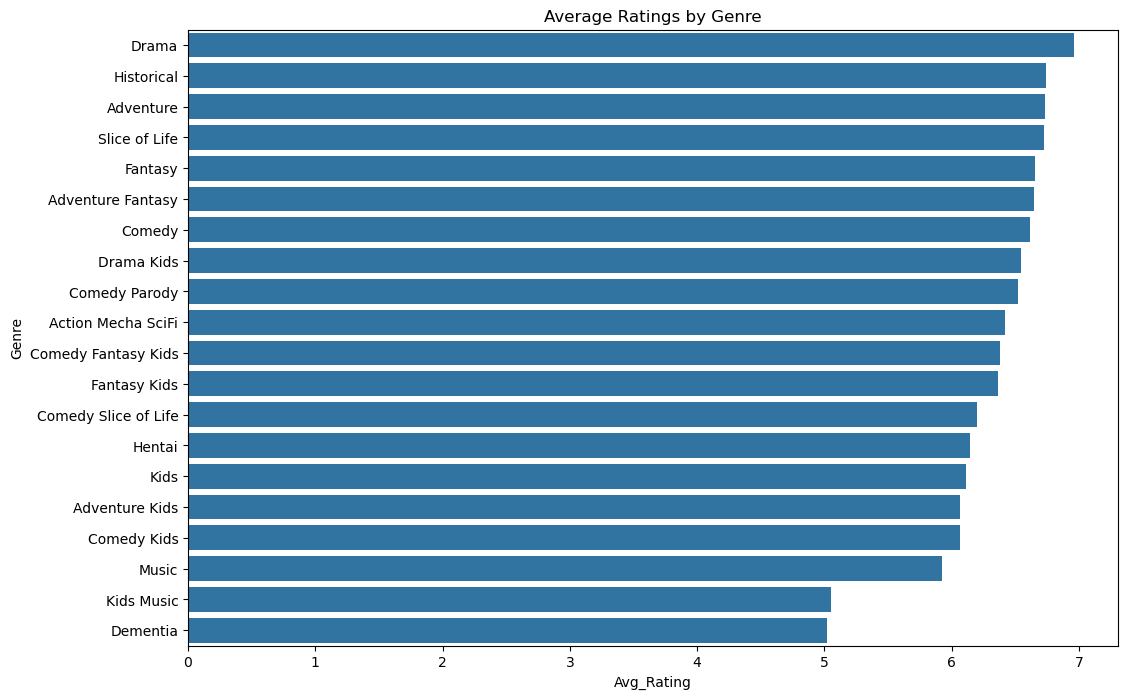

In [204]:
from collections import Counter

# Analyze genre frequency
all_genres = [genre for sublist in anime['genre_list'] for genre in sublist]
genre_counts = Counter(all_genres)

top_genres = pd.DataFrame(genre_counts.most_common(20), columns=['Genre', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(data=top_genres, y='Genre', x='Count')
plt.title('Top 20 Most Common Genres')
plt.show()

# Genre and ratings
genre_ratings = {}
for genre in top_genres['Genre']:
    mask = anime['genre'].str.contains(genre, na=False)
    genre_ratings[genre] = anime[mask]['rating'].mean()

genre_ratings_df = pd.DataFrame(list(genre_ratings.items()), columns=['Genre', 'Avg_Rating'])
genre_ratings_df = genre_ratings_df.sort_values('Avg_Rating', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=genre_ratings_df, y='Genre', x='Avg_Rating')
plt.title('Average Ratings by Genre')
plt.show()